# Análisis Exploratorio de Datos - Datos_guerras_tidy.csv

Este notebook realiza un análisis exploratorio completo del archivo de datos, utilizando todas las funciones disponibles en `data_explorer.py` para una revisión exhaustiva de los datos.

## 0. Instalación de Dependencias

In [1]:
import subprocess
import sys

# Instalar dependencias requeridas
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

## 1. Importar Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_explorer import DataExplorer
import warnings

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

## 2. Cargar y Explorar Datos

In [3]:
archivo = "Datos_guerras_tidy.csv"

# Intentar cargar con diferentes delimitadores
try:
    df = pd.read_csv(archivo, sep=',')
    print("✓ Archivo cargado con delimitador COMA")
except:
    try:
        df = pd.read_csv(archivo, sep=';')
        print("✓ Archivo cargado con delimitador PUNTO Y COMA")
    except:
        try:
            df = pd.read_csv(archivo, sep='\\t')
            print("✓ Archivo cargado con delimitador TAB")
        except:
            try:
                df = pd.read_csv(archivo, sep='\\s+')
                print("✓ Archivo cargado con delimitador WHITESPACE")
            except:
                df = pd.read_csv(archivo)
                print("✓ Archivo cargado con delimitador por defecto")

print(f"\\n✓ Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"  Tamaño en memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

✓ Archivo cargado con delimitador COMA
\n✓ Dimensiones: 17556 filas × 6 columnas
  Tamaño en memoria: 4.97 MB


## 3. Vista Previa de Datos

In [4]:
print("\\n=== PRIMERAS FILAS ===")
print(df.head(10))

print("\\n=== ÚLTIMAS FILAS ===")
print(df.tail())

print("\\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\\n=== INFORMACIÓN GENERAL ===")
print(df.info())

\n=== PRIMERAS FILAS ===
             Country Name Country Code  \
0                   Aruba          ABW   
1                     NaN          AFE   
2              Afganistán          AFG   
3                     NaN          AFW   
4                  Angola          AGO   
5                 Albania          ALB   
6                 Andorra          AND   
7          El mundo árabe          ARB   
8  Emiratos Árabes Unidos          ARE   
9               Argentina          ARG   

                                      Indicator Name Indicator Code    Year  \
0  Muertes producto de la guerra (cantidad de per...    VC.BTL.DETH  1960.0   
1  Muertes producto de la guerra (cantidad de per...    VC.BTL.DETH  1960.0   
2  Muertes producto de la guerra (cantidad de per...    VC.BTL.DETH  1960.0   
3  Muertes producto de la guerra (cantidad de per...    VC.BTL.DETH  1960.0   
4  Muertes producto de la guerra (cantidad de per...    VC.BTL.DETH  1960.0   
5  Muertes producto de la guerra (cant

## 4. Crear Instancia de DataExplorer

In [5]:
explorer = DataExplorer(df, verbose=True)

## 5. Resumen Estructural de Datos

In [6]:
resumen_estructural = explorer.get_structural_summary()
print("Resumen Estructural:")
print(resumen_estructural)


=== Structural Summary ===
                    metric   value
                Total rows   17556
             Total columns       6
              Memory usage 4.97 MB
           Numeric columns       2
       Categorical columns       0
           Boolean columns       0
          Datetime columns       0
         Free-text columns       0
Unknown/mixed type columns       4
Large dataset (rows >500k)   False
   Wide dataset (cols >50)   False
Resumen Estructural:
                        metric    value
0                   Total rows    17556
1                Total columns        6
2                 Memory usage  4.97 MB
3              Numeric columns        2
4          Categorical columns        0
5              Boolean columns        0
6             Datetime columns        0
7            Free-text columns        0
8   Unknown/mixed type columns        4
9   Large dataset (rows >500k)    False
10     Wide dataset (cols >50)    False


## 6. Análisis de Valores Faltantes

In [17]:
analisis_nulos = explorer.analyze_nulls()


=== Null Analysis ===
                null_count   null_pct
Deaths               16056  91.455913
Country Name           132   0.751880
Country Code             0   0.000000
Indicator Name           0   0.000000
Indicator Code           0   0.000000
Year                     0   0.000000


In [20]:
explorer.df

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Deaths
0,Aruba,ABW,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,1960.0,NaN
1,NaN,AFE,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,1960.0,NaN
2,Afganistán,AFG,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,1960.0,NaN
3,NaN,AFW,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,1960.0,NaN
4,Angola,AGO,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,1960.0,NaN
...,...,...,...,...,...,...
17551,Kosovo,XKX,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,2025.0,NaN
17552,"Yemen, Rep. del",YEM,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,2025.0,NaN
17553,Sudáfrica,ZAF,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,2025.0,NaN
17554,Zambia,ZMB,Muertes producto de la guerra (cantidad de per...,VC.BTL.DETH,2025.0,NaN


## 7. Análisis de Duplicados

In [8]:
analisis_duplicados = explorer.analyze_duplicates()
print("Análisis de Duplicados:")
for key, value in analisis_duplicados.items():
    print(f"  {key}: {value}")


=== Duplicate Analysis ===
  Full duplicate rows: 0
Análisis de Duplicados:
  full_duplicates: 0
  id_duplicates: None
  duplicated_ids: None


## 8. Detección de Variables con Baja Varianza

In [9]:
bajo_varianza = explorer.detect_low_variance()
print(f"Variables con baja varianza detectadas: {len(bajo_varianza)}")
if bajo_varianza:
    print("Columnas:", bajo_varianza)


=== Low Variance Detection ===
  No low-variance columns detected.
Variables con baja varianza detectadas: 0


## 9. Detección de Outliers

In [ ]:
outliers_df = explorer.detect_outliers()


=== Outlier Detection ===
  Method: iqr, threshold: 1.5
        n_outliers  pct_outliers  lower_bound  upper_bound
column                                                    
Year             0          0.00     1926.500     2058.500
Deaths         217         14.47    -3758.625     6464.375


## 10. Análisis de Normalidad - Gráficos Q-Q

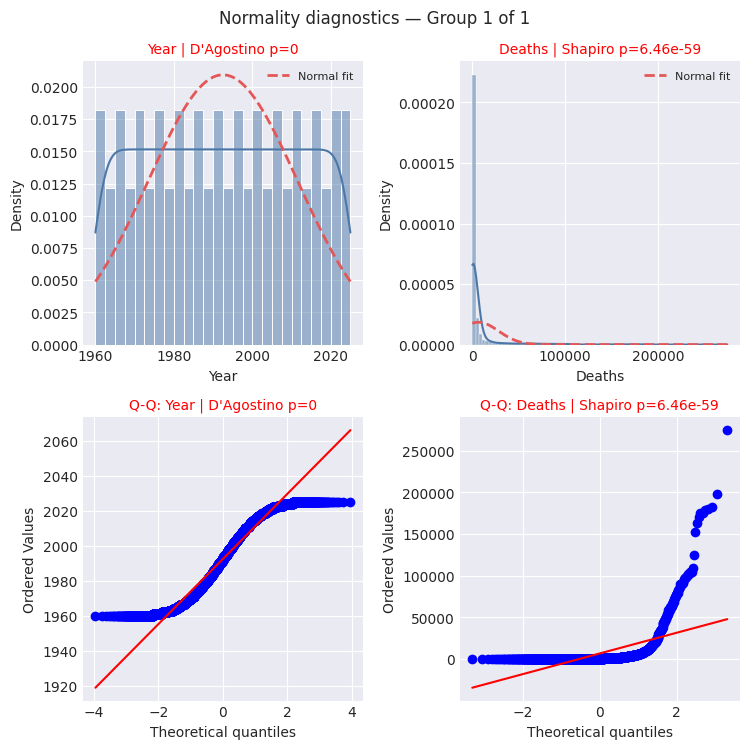

<Figure size 640x480 with 0 Axes>

In [11]:
fig = explorer.plot_normality()
plt.tight_layout()
plt.show()

## 11. Matriz de Correlación

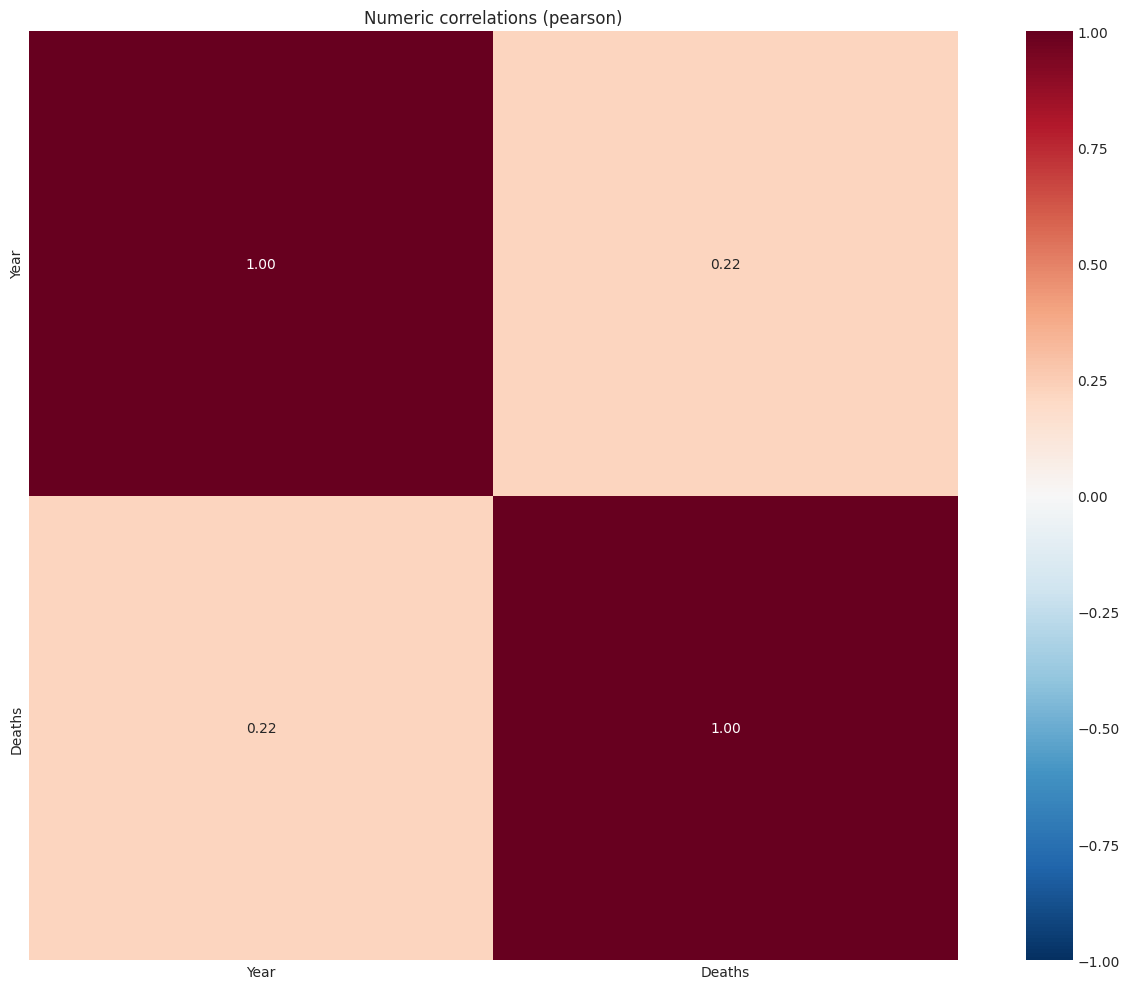

<Figure size 640x480 with 0 Axes>

In [12]:
fig = explorer.plot_correlation_heatmap()
plt.tight_layout()
plt.show()

## 12. Gráficos Scatter de Relaciones Bivariadas

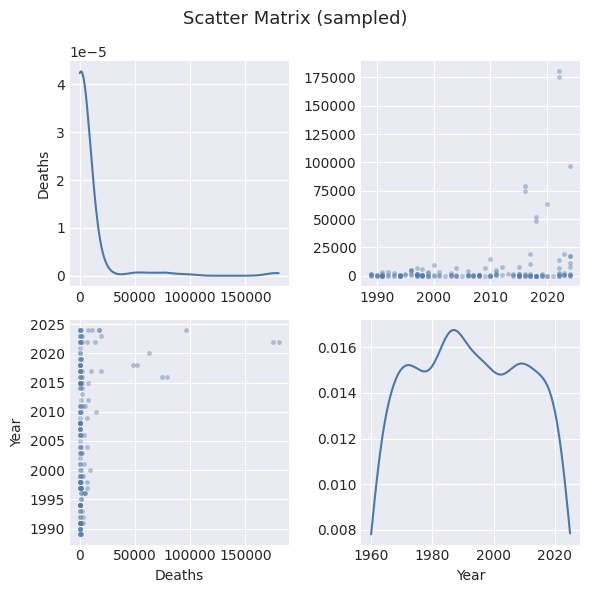

<Figure size 640x480 with 0 Axes>

In [13]:
try:
    fig = explorer.plot_scatter()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Nota: No se pudieron generar scatter plots. Razón: {str(e)[:100]}")

## 13. Resumen de Alertas y Problemas Detectados

In [14]:
alerts_df = explorer.generate_alert_summary()
print(f"Total de alertas: {len(alerts_df)}\\n")
if len(alerts_df) > 0:
    print(alerts_df)


=== Alert Summary ===
severity  category                                                                           message affected_columns
CRITICAL     nulls                                            Column 'Deaths' has 91.5% nulls (>90%)           Deaths
 WARNING  outliers                                        Column 'Deaths' has 14.47% outliers (>10%)           Deaths
 WARNING normality Columns failing normality: ['Year', 'Deaths']. This may affect model assumptions.     Year, Deaths
Total de alertas: 3\n
   severity   category                                            message  \
0  CRITICAL      nulls             Column 'Deaths' has 91.5% nulls (>90%)   
1   WARNING   outliers         Column 'Deaths' has 14.47% outliers (>10%)   
2   WARNING  normality  Columns failing normality: ['Year', 'Deaths']....   

  affected_columns  
0           Deaths  
1           Deaths  
2     Year, Deaths  


## 14. Pipeline Summary para Downstream Processing

In [15]:
pipeline_summary = explorer.get_pipeline_summary()
print("Pipeline Summary para Downstream Processing:")
print(f"  Número de variables numéricas: {len(pipeline_summary['numeric_cols'])}")
print(f"  Número de variables categóricas: {len(pipeline_summary['categorical_cols'])}")
print(f"  Columnas con valores faltantes: {len(pipeline_summary['null_columns'])}")
print(f"  Columnas de baja varianza: {len(pipeline_summary['low_variance_cols'])}")
print(f"\\nVARIABLES NUMÉRICAS:")
print(pipeline_summary['numeric_cols'][:10])
print(f"\\nVARIABLES CATEGÓRICAS:")
print(pipeline_summary['categorical_cols'][:10])


=== Low Variance Detection ===
  No low-variance columns detected.

=== Outlier Detection ===
  Method: iqr, threshold: 1.5
        n_outliers  pct_outliers  lower_bound  upper_bound
column                                                    
Year             0          0.00     1926.500     2058.500
Deaths         217         14.47    -3758.625     6464.375

=== Duplicate Analysis ===
  Full duplicate rows: 0

=== Tidy Format Check ===
Dataset appears to be in tidy format.

=== Alert Summary ===
severity  category                                                                           message affected_columns
CRITICAL     nulls                                            Column 'Deaths' has 91.5% nulls (>90%)           Deaths
 WARNING  outliers                                        Column 'Deaths' has 14.47% outliers (>10%)           Deaths
 WARNING normality Columns failing normality: ['Year', 'Deaths']. This may affect model assumptions.     Year, Deaths
 WARNING  outliers        

## 15. Análisis EDA Completo


=== Tidy Format Check ===
Dataset appears to be in tidy format.

=== Structural Summary ===
                    metric   value
                Total rows   17556
             Total columns       6
              Memory usage 4.97 MB
           Numeric columns       2
       Categorical columns       0
           Boolean columns       0
          Datetime columns       0
         Free-text columns       0
Unknown/mixed type columns       4
Large dataset (rows >500k)   False
   Wide dataset (cols >50)   False

=== Null Analysis ===
                null_count   null_pct
Deaths               16056  91.455913
Country Name           132   0.751880
Country Code             0   0.000000
Indicator Name           0   0.000000
Indicator Code           0   0.000000
Year                     0   0.000000

=== Duplicate Analysis ===
  Full duplicate rows: 0

=== Target Analysis ===
  No target column specified; skipping.

=== Low Variance Detection ===
  No low-variance columns detected.

=== Outlier

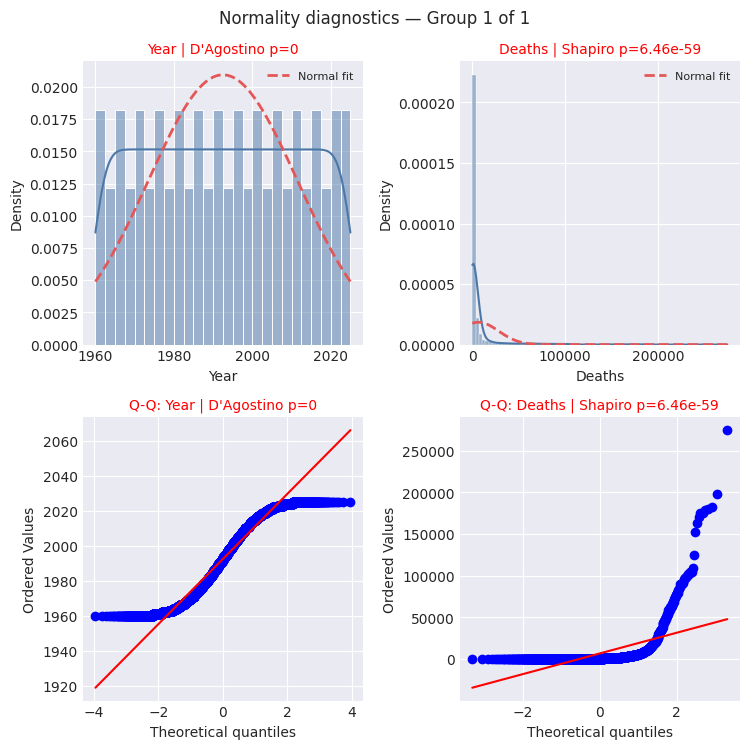

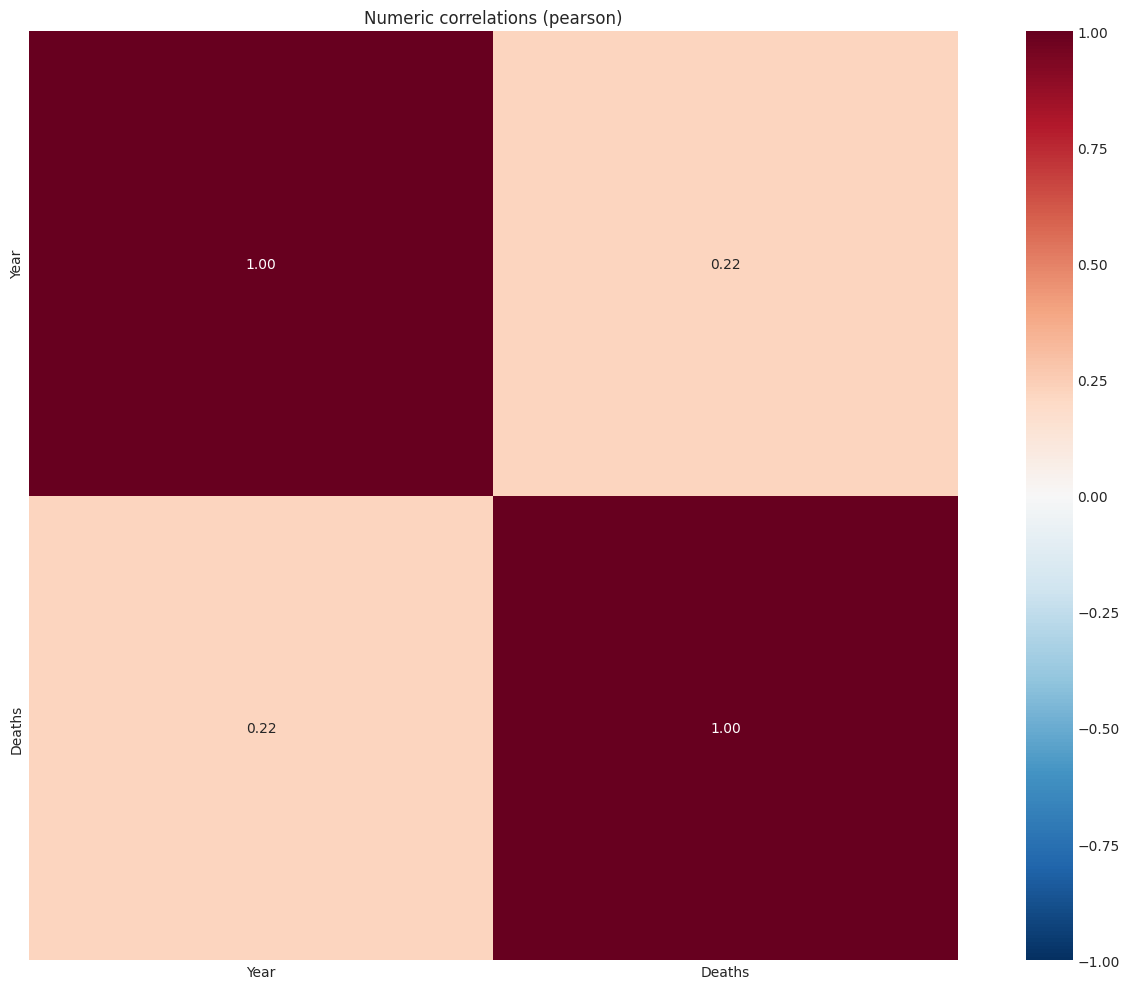


=== Target Correlations ===
  No target column specified; skipping.


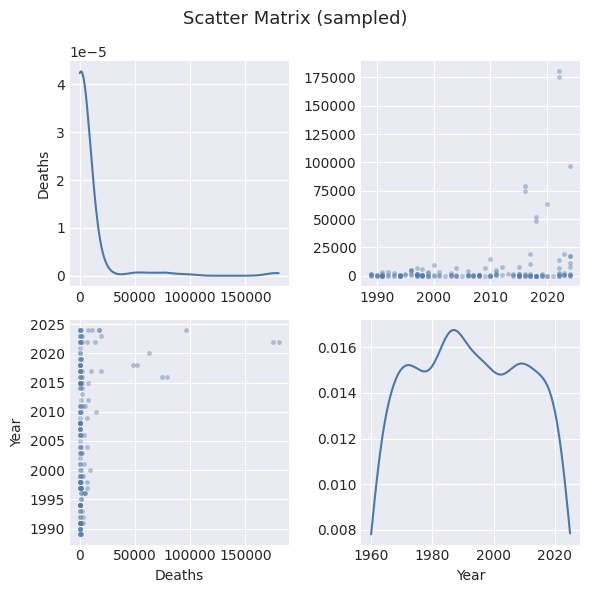

Sweetviz is not installed. Install with: pip install sweetviz

=== Alert Summary ===
severity  category                                                                           message affected_columns
CRITICAL     nulls                                            Column 'Deaths' has 91.5% nulls (>90%)           Deaths
CRITICAL     nulls                                            Column 'Deaths' has 91.5% nulls (>90%)           Deaths
 WARNING normality Columns failing normality: ['Year', 'Deaths']. This may affect model assumptions.     Year, Deaths
 WARNING  outliers                                        Column 'Deaths' has 14.47% outliers (>10%)           Deaths
 WARNING  outliers                                        Column 'Deaths' has 14.47% outliers (>10%)           Deaths
 WARNING  outliers                                        Column 'Deaths' has 14.47% outliers (>10%)           Deaths
 WARNING normality Columns failing normality: ['Year', 'Deaths']. This may affect model a

In [16]:
full_eda = explorer.run_full_eda()
print("✓ Análisis EDA completo ejecutado exitosamente")
print(f"  Secciones generadas: {len(full_eda)} componentes")